In [91]:
# Mengimpor pustaka untuk pengolahan data, perhitungan, visualisasi, dan K-Means
import pandas as pd                  # Membaca dan mengolah data berbentuk tabel
import numpy as np                   # Melakukan perhitungan numerik
import matplotlib.pyplot as plt      # Membuat grafik
import seaborn as sns                # Membuat visualisasi statistik
from sklearn.cluster import KMeans   # Menjalankan algoritma clustering K-Means
from sklearn.metrics import silhouette_score  # Mengevaluasi kualitas hasil clustering


In [92]:
# Membaca dataset CSV dan menyimpannya sebagai DataFrame bernama df
df = pd.read_csv('E:\colabbbbbbbbbbbbbbbbbbbbbb\dataset\covid_19_indonesia_time_series_all.csv')

# Menampilkan isi dataset
df


<>:2: SyntaxWarning: "\c" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\c"? A raw string is also an option.
<>:2: SyntaxWarning: "\c" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\c"? A raw string is also an option.
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_22820\3897344075.py:2: SyntaxWarning: "\c" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\c"? A raw string is also an option.
  df = pd.read_csv('E:\colabbbbbbbbbbbbbbbbbbbbbb\dataset\covid_19_indonesia_time_series_all.csv')


,Date,Location ISO Code,Location,New Cases,New Deaths,New Recovered,New Active Cases,Total Cases,Total Deaths,Total Recovered,...,Latitude,New Cases per Million,Total Cases per Million,New Deaths per Million,Total Deaths per Million,Total Deaths per 100rb,Case Fatality Rate,Case Recovered Rate,Growth Factor of New Cases,Growth Factor of New Deaths
0,3/1/2020,ID-JK,DKI Jakarta,2,0,0,2,39,20,75,...,-6.204699,0.18,3.60,0.0,1.84,0.18,51.28%,192.31%,NaN,NaN
1,3/2/2020,ID-JK,DKI Jakarta,2,0,0,2,41,20,75,...,-6.204699,0.18,3.78,0.0,1.84,0.18,48.78%,182.93%,1.00,1.00
2,3/2/2020,IDN,Indonesia,2,0,0,2,2,0,0,...,-0.789275,0.01,0.01,0.0,0.00,0.00,0.00%,0.00%,NaN,NaN
3,3/2/2020,ID-RI,Riau,1,0,0,1,1,0,1,...,0.511648,0.16,0.16,0.0,0.00,0.00,0.00%,100.00%,NaN,NaN
4,3/3/2020,ID-JK,DKI Jakarta,2,0,0,2,43,20,75,...,-6.204699,0.18,3.96,0.0,1.84,0.18,46.51%,174.42%,1.00,1.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31817,9/15/2022,ID-SA,Sulawesi Utara,37,0,0,37,52770,1213,50997,...,1.259638,14.01,19974.38,0.0,459.14,45.91,2.30%,96.64%,2.85,1.00
31818,9/15/2022,ID-SB,Sumatera Barat,13,0,3,10,104640,2371,102066,...,-0.850253,2.36,18959.11,0.0,429.59,42.96,2.27%,97.54%,6.50,1.00
31819,9/15/2022,ID-SS,Sumatera Selatan,16,0,1,15,82198,3376,78510,...,-3.216212,1.95,10002.74,0.0,410.83,41.08,4.11%,95.51%,3.20,1.00
31820,9/15/2022,ID-SU,Sumatera Utara,50,0,5,45,158866,3288,154924,...,2.191894,3.36,10680.15,0.0,221.04,22.10,2.07%,97.52%,1.92,1.00


In [93]:
# Memilih kolom yang dibutuhkan, mengelompokkan data berdasarkan provinsi,
# lalu mengambil nilai kasus dan kematian tertinggi pada setiap provinsi
db = df[['Total Cases', 'Province', 'Total Deaths']].groupby('Province').agg('max')

# Menampilkan data hasil pengelompokan
db


,Total Cases,Total Deaths
Province,,
Aceh,44038,2223
Bali,166831,4731
Banten,333875,2950
Bengkulu,29173,522
DKI Jakarta,1412511,15513
Daerah Istimewa Yogyakarta,224307,5928
Gorontalo,13951,487
Jambi,38643,889
Jawa Barat,1173731,15937


Text(0, 0.5, 'Total Deaths')

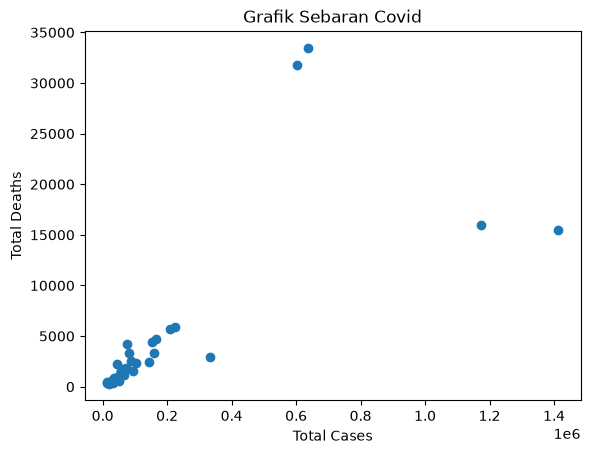

In [94]:
# Membuat grafik sebaran awal antara total kasus dan total kematian
plt.scatter(db['Total Cases'], db['Total Deaths'])
plt.title('Grafik Sebaran Covid')       # Memberi judul grafik
plt.xlabel('Total Cases')               # Memberi label sumbu horizontal
plt.ylabel('Total Deaths')              # Memberi label sumbu vertikal


In [95]:
# Mengimpor dan membuat model K-Means dengan tiga kelompok
from sklearn.cluster import KMeans
km = KMeans(n_clusters=3)

# Menampilkan konfigurasi model
km


,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",3
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary <random_state>`.",None
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


In [96]:
# Mengimpor MinMaxScaler untuk menyamakan rentang nilai setiap fitur
from sklearn.preprocessing import MinMaxScaler

# Membuat objek scaler
scaler = MinMaxScaler()

# Mengubah Total Cases dan Total Deaths ke rentang 0 sampai 1
new = pd.DataFrame(
    scaler.fit_transform(db[['Total Cases', 'Total Deaths']]),
    columns=['Total Cases', 'Total Deaths']
)

# Melatih K-Means sekaligus memprediksi nomor kelompok setiap provinsi
y_predicted = km.fit_predict(new[['Total Cases', 'Total Deaths']])
y_predicted

# Menambahkan hasil nomor kelompok ke DataFrame db
db['Kelompok'] = y_predicted

# Menampilkan data beserta kelompoknya
db


,Total Cases,Total Deaths,Kelompok
Province,,,
Aceh,44038,2223,0
Bali,166831,4731,0
Banten,333875,2950,0
Bengkulu,29173,522,0
DKI Jakarta,1412511,15513,2
Daerah Istimewa Yogyakarta,224307,5928,0
Gorontalo,13951,487,0
Jambi,38643,889,0
Jawa Barat,1173731,15937,2


Text(0.5, 1.0, 'Grafik Sebaran Covid')

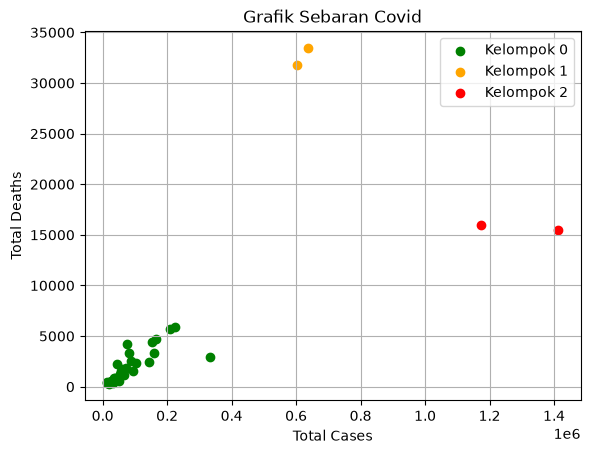

In [97]:
# Memisahkan data berdasarkan hasil kelompok K-Means
new1 = db[db.Kelompok == 0]
new2 = db[db.Kelompok == 1]
new3 = db[db.Kelompok == 2]

# Menampilkan setiap kelompok dengan warna berbeda
plt.scatter(new1['Total Cases'], new1['Total Deaths'], color='green', label='Kelompok 0')
plt.scatter(new2['Total Cases'], new2['Total Deaths'], color='orange', label='Kelompok 1')
plt.scatter(new3['Total Cases'], new3['Total Deaths'], color='red', label='Kelompok 2')

# Mengatur keterangan grafik hasil clustering
plt.xlabel('Total Cases')
plt.ylabel('Total Deaths')
plt.grid()
plt.legend()
plt.title('Grafik Sebaran Covid')


In [98]:
# Mengevaluasi jumlah cluster menggunakan tiga metode
from sklearn.metrics import silhouette_score, davies_bouldin_score

hasil_evaluasi = []

# Membandingkan jumlah cluster dari 2 sampai 10
for jumlah_cluster in range(2, 11):
    model_evaluasi = KMeans(
        n_clusters=jumlah_cluster,
        random_state=42,
        n_init='auto'
    )
    label_evaluasi = model_evaluasi.fit_predict(new)

    hasil_evaluasi.append({
        'Jumlah Cluster': jumlah_cluster,
        'Inertia': model_evaluasi.inertia_,
        'Silhouette Score': silhouette_score(new, label_evaluasi),
        'Davies-Bouldin Index': davies_bouldin_score(new, label_evaluasi)
    })

# Menampilkan tabel perbandingan hasil evaluasi
evaluasi_df = pd.DataFrame(hasil_evaluasi)
display(evaluasi_df.round(4))

# Mengambil hasil terbaik untuk membantu penjelasan
cluster_silhouette_terbaik = int(
    evaluasi_df.loc[evaluasi_df['Silhouette Score'].idxmax(), 'Jumlah Cluster']
)
cluster_dbi_terbaik = int(
    evaluasi_df.loc[evaluasi_df['Davies-Bouldin Index'].idxmin(), 'Jumlah Cluster']
)
hasil_cluster_3 = evaluasi_df[evaluasi_df['Jumlah Cluster'] == 3]

print('=== PENJELASAN TIGA METODE EVALUASI ===')
print(
    '1. Inertia mengukur total jarak setiap data terhadap pusat cluster. '
    'Nilai lebih kecil menunjukkan anggota cluster lebih rapat. Nilai ini '
    'selalu menurun saat jumlah cluster bertambah, sehingga tidak digunakan sendirian.'
)
print(
    f'2. Silhouette Score mengukur kekompakan dan pemisahan cluster. '
    f'Nilai terbaik adalah yang paling mendekati 1. Hasil tertinggi terdapat '
    f'pada k={cluster_silhouette_terbaik}, yaitu '
    f'{evaluasi_df["Silhouette Score"].max():.4f}.'
)
print(
    f'3. Davies-Bouldin Index mengukur kemiripan antar-cluster. '
    f'Nilai lebih kecil berarti cluster lebih terpisah. Hasil terendah terdapat '
    f'pada k={cluster_dbi_terbaik}, yaitu '
    f'{evaluasi_df["Davies-Bouldin Index"].min():.4f}.'
)

print('\n=== HASIL MODEL 3 CLUSTER ===')
display(hasil_cluster_3.round(4))

if cluster_silhouette_terbaik == cluster_dbi_terbaik == 3:
    print(
        'Kesimpulan: 3 cluster dipilih karena memperoleh Silhouette Score '
        'tertinggi dan Davies-Bouldin Index terendah. Inertia digunakan sebagai '
        'informasi tambahan mengenai kerapatan cluster.'
    )
else:
    print(
        'Kesimpulan: hasil metode berbeda. Pemilihan jumlah cluster perlu '
        'mempertimbangkan seluruh metrik dan kebutuhan interpretasi data.'
    )


,Jumlah Cluster,Inertia,Silhouette Score,Davies-Bouldin Index
0,2,0.6596,0.8635,0.4519
1,3,0.1680,0.9035,0.1591
2,4,0.0695,0.6482,0.3703
3,5,0.0476,0.5442,0.5304
4,6,0.0352,0.5623,0.4158
5,7,0.0206,0.5174,0.3307
6,8,0.0156,0.4726,0.3226
7,9,0.0140,0.4191,0.2839
8,10,0.0078,0.4362,0.3491


=== PENJELASAN TIGA METODE EVALUASI ===
1. Inertia mengukur total jarak setiap data terhadap pusat cluster. Nilai lebih kecil menunjukkan anggota cluster lebih rapat. Nilai ini selalu menurun saat jumlah cluster bertambah, sehingga tidak digunakan sendirian.
2. Silhouette Score mengukur kekompakan dan pemisahan cluster. Nilai terbaik adalah yang paling mendekati 1. Hasil tertinggi terdapat pada k=3, yaitu 0.9035.
3. Davies-Bouldin Index mengukur kemiripan antar-cluster. Nilai lebih kecil berarti cluster lebih terpisah. Hasil terendah terdapat pada k=3, yaitu 0.1591.

=== HASIL MODEL 3 CLUSTER ===


,Jumlah Cluster,Inertia,Silhouette Score,Davies-Bouldin Index
1,3,0.168,0.9035,0.1591


Kesimpulan: 3 cluster dipilih karena memperoleh Silhouette Score tertinggi dan Davies-Bouldin Index terendah. Inertia digunakan sebagai informasi tambahan mengenai kerapatan cluster.
